# Rate-Distortion Curve plotting from W&B Project

---


#### Imports and global settings


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import wandb
from omegaconf import OmegaConf, DictConfig
from pathlib import Path
from pprint import pprint
import json


# Quick ANSI color code shortcurts
r = "\033[31m"
y = "\033[33m"
g = "\033[32m"
b = "\033[34m"
e = "\033[0m"

api = wandb.Api()
# Project is specified by <entity/project-name>
entity: str = "cedric-leonard"
project: str = "SAR_DDC_FPGA"  # "SAR_DDC-RD-curve"
runs = api.runs(f"{entity}/{project}")
nb_all_runs = len(runs)
print(f"{b}Found {nb_all_runs} runs in project {entity}/{project}{e}")

path_to_csv_results = Path("../data/RD-curve_results/test1.csv")

verbose = False
save_loaded_project = False

Found 110 runs in project cedric-leonard/SAR_DDC_FPGA


#### Config loading


In [2]:
run_name_list, id_list, summary_list, config_list = [], [], [], []
data_name_list, model_name_list, lmbda_list, seed_list = [], [], [], []
out_pad_list = []

for i, run in enumerate(runs):
    # Transform the wandb config in a DictConfig object (to be able to easily access nested keys)
    config = OmegaConf.create(run.config)

    run_name_list.append(run.name)  # .name is the human-readable name of the run.
    id_list.append(run.id)  # .id is the unique id of the run (used in logs and the URL).
    # .summary contains the output keys/values for metrics like accuracy. We call ._json_dict to omit large files
    summary_list.append(run.summary._json_dict)

    if verbose and i == 0:
        print(f"Run N°{i} ({r}{run.id}{e}, '{run.name}') summary:")
        print(f"BPP of Run N°{i} = {summary_list[i]['test/bpp']} and its config:")
        # pprint(summary_list[i]["test/bpp"])
        pprint(run.config)
        # pprint(run.history())

    # Store the model name, lmbda (rate-distortion tradeoff) and the seed in separate lists (for easier access)
    dl_model_name = OmegaConf.select(config, "model.net._target_").split(".")[-1]
    prefix = run.name.split("_")[0]
    activation_name = prefix.split("-")[1] if "-" in prefix else "gdn"

    model_name_list.append(f"{dl_model_name}_{activation_name}")
    lmbda_list.append(OmegaConf.select(config, "model.criterion.lmbda"))
    seed_list.append(OmegaConf.select(config, "seed"))
    # Get the dataset name from the config "data._target_" last part (after the last dot)
    data_name_list.append(
        OmegaConf.select(config, "data._target_").split(".")[-1]
    )  # e.g., EuroSATRGBDataModule or EuroSATSARDataModule
    out_pad_list.append(OmegaConf.select(config, "model.net.no_output_padding"))

    #  Store the full config (just in case), remove special values that start with _.
    config_list.append({k: v for k, v in run.config.items()})  # if not k.startswith("_")})

# print(f"{len(model_name_list)=}, {len(lmbda_list)=}, {len(seed_list)=}, {len(config_list)=}")

# Create a dataframe with all the information
raw_runs_df = pd.DataFrame(
    {
        "id": id_list,
        "run_name": run_name_list,
        "data_name": data_name_list,
        "model_name": model_name_list,
        "lmbda": lmbda_list,
        "seed": seed_list,
        "out_pad": out_pad_list,
        "summary": summary_list,
        "config": config_list,
    }
)

# Set the index of the datafrane to be the run id
raw_runs_df.set_index("id", inplace=True)

# Save the dataframe to a csv file
if save_loaded_project:
    csv_file_path = f"{project}.csv"
    raw_runs_df.to_csv(csv_file_path)
    print(f"Dataframe saved to {b}{csv_file_path}{e}")
print(f"Project {b}{project}{e} contains {r}{nb_all_runs}{e} runs.")

Project SAR_DDC_FPGA contains 110 runs.


## Filtering / Run cleaning

_This part is super **specific** and should probably be checked/changed everytime the goal of this script is different_


In [3]:
# ----- Clean the dataframe  from unwanted runs ----- #
# Remove runs run without a specific seed
runs_df = raw_runs_df[
    raw_runs_df["seed"].isin([0, 1, 2, 3, 4])
]  # The GTs (ADAM-NOC and MERLIN) use seed = 42

# Check for "debug" tags in the config, remove runs that have them
runs_df = runs_df[
    ~runs_df["config"].apply(lambda x: "debug" in x["tags"] or "crashed" in x["tags"])
]

# Remove runs that do not have a "test/psnr" key in the summary ("crashed run")
runs_df = runs_df[runs_df["summary"].apply(lambda x: "test/bpp" in x.keys())]

# filter out runs whose run_name does not start by "ResSHyp" or "ResAE"
runs_df = runs_df[
    runs_df["run_name"].str.startswith("ResSHyp") | runs_df["run_name"].str.startswith("ResAE")
]

# ----- Filter runs with "diverging"/"unnecessary" lmbda values ----- #
runs_df = runs_df[~runs_df["lmbda"].isin([0.25, 0.5, 1.5])]
# runs_df = runs_df[runs_df["lmbda"].isin([0.1, 0.5, 1, 2, 5, 10, 25, 50, 100, 200, 500])]

# ----- Print the remaining runs ----- #
nb_filtered_runs = len(runs_df)
print(
    f"{r}{nb_all_runs - nb_filtered_runs}{e} runs were filtered out, {g}{nb_filtered_runs}{e} runs were kept."
)

16 runs were filtered out, 94 runs were kept.


In [4]:
# --- Print unique model, lambda and seed per dataset ---
for i, name in enumerate(runs_df["data_name"].unique()):
    dataset_runs = runs_df[runs_df["data_name"] == name]
    unique_models = dataset_runs["model_name"].unique()
    unique_lmbda = dataset_runs["lmbda"].unique()
    unique_seeds = dataset_runs["seed"].unique()
    unique_out_pad = dataset_runs["out_pad"].unique()
    print(
        f"{r}{name}{e} ({g}{len(dataset_runs)}{e}) unique:\n"
        f"\t-  models: {g}{len(unique_models)}{e}, {unique_models}\n"
        f"\t- out_pad: {g}{len(unique_out_pad)}{e}, {unique_out_pad}\n"
        f"\t-  lambda: {g}{len(unique_lmbda)}{e}, {sorted(unique_lmbda.astype(float).tolist())}\n"
        f"\t-   seeds: {g}{len(unique_seeds)}{e}, {sorted(unique_seeds.astype(int).tolist())}\n"
    )
    expected_nb_runs = (
        len(unique_models) * len(unique_lmbda) * len(unique_seeds) * len(unique_out_pad)
    )
    if len(dataset_runs) != expected_nb_runs:
        print(
            f"   {y}Warning{e}: for all the unique values {b}{expected_nb_runs}{e} where expected! {b}{expected_nb_runs - len(dataset_runs)}{e} are missing.\n"
        )

# Print all run hierarchically grouped by dataset, model, out_pad, lmbda, seed
for dataset in runs_df["data_name"].unique():
    dataset_runs = runs_df[runs_df["data_name"] == dataset]
    print(f"{b}Dataset: {dataset}{e}")
    for model in dataset_runs["model_name"].unique():
        model_runs = dataset_runs[dataset_runs["model_name"] == model]
        print(f"  {g}Model: {model}{e}")
        for out_pad in model_runs["out_pad"].unique():
            out_pad_runs = model_runs[model_runs["out_pad"] == out_pad]
            print(f"    {b}Out_pad: {out_pad}{e}")
            for lmbda in sorted(out_pad_runs["lmbda"].unique().astype(float).tolist()):
                lmbda_runs = out_pad_runs[out_pad_runs["lmbda"] == lmbda]
                print(f"      {r}Lambda: {lmbda}{e}")
                for seed in sorted(lmbda_runs["seed"].unique().astype(int).tolist()):
                    seed_runs = lmbda_runs[lmbda_runs["seed"] == seed]
                    for run_id in seed_runs.index:
                        print(f"        Seed: {seed} -> Run ID: {run_id}")

# Print the run_ids of the run with "data_name" == "EuroSATSARDataModule" and "model_name" == "mbt2018"
# print(
#     list(
#         runs_df[
#             (runs_df["data_name"] == "EuroSATSARDataModule")
#             & (runs_df["model_name"] == "mbt2018")
#         ].index
#     )
# )

TSXSSCDataModule (94) unique:
	-  models: 1, ['ResidualScaleHyperpriorPatched_gdn']
	- out_pad: 2, [True False]
	-  lambda: 10, [1.0, 2.0, 5.0, 10.0, 20.0, 50.0, 100.0, 200.0, 500.0, 1000.0]
	-   seeds: 4, [0, 1, 2, 3]


Dataset: TSXSSCDataModule
  Model: ResidualScaleHyperpriorPatched_gdn
    Out_pad: True
      Lambda: 1.0
        Seed: 0 -> Run ID: dmccxmpr
        Seed: 1 -> Run ID: f40akucm
      Lambda: 2.0
        Seed: 0 -> Run ID: n6nyzmks
        Seed: 1 -> Run ID: qoi4ivp8
        Seed: 2 -> Run ID: db4vmcpz
        Seed: 2 -> Run ID: akhsswfd
        Seed: 3 -> Run ID: mg9jdmfi
      Lambda: 5.0
        Seed: 0 -> Run ID: tz5bsl0a
        Seed: 1 -> Run ID: mc690npb
        Seed: 2 -> Run ID: icjuqqz0
        Seed: 2 -> Run ID: cj6a6w18
        Seed: 3 -> Run ID: 1i4v5jgo
      Lambda: 10.0
        Seed: 0 -> Run ID: ioc39y19
        Seed: 1 -> Run ID: bdxp6z4w
        Seed: 2 -> Run ID: nrkg1dkt
        Seed: 2 -> Run ID: rfiwkrwr
        Seed: 3 -> Run ID: ab9fnhi4
      

#### Group and statistics


In [5]:
# --- List of specific metrics to track for each model ---
metrics_of_interest = ["test/bpp"]
for metric in ["psnr", "ssim", "ms_ssim"]:  # "mse"
    metrics_of_interest.append(f"test/{metric}")
    metrics_of_interest.append(f"test/{metric}_merlin")
    metrics_of_interest.append(f"test/{metric}_adam_noc")
statistics_of_interest = ["mean", "min", "max", "std"]
metrics_to_track = []
for metric in metrics_of_interest:
    for stat in statistics_of_interest:
        metrics_to_track.append(f"{metric} {stat}")

model_statistics = {}
# --- For each dataset ---
for data_name, df_data in runs_df.groupby("data_name"):
    # Append the list of metrics to track to the dictionanry
    model_statistics[data_name] = {}
    # --- For each model ---
    for (model_name, out_pad), df_model in df_data.groupby(["model_name", "out_pad"]):
        # Create an empty dataframe that will contain a column for each metric (test/psnr, test/bpp) and a row for each lmbda value
        lmbda_values = df_model["lmbda"].unique()
        stats_dataframe = pd.DataFrame(index=lmbda_values, columns=metrics_to_track)
        stats_dataframe.sort_index(inplace=True)  # Sort the index (only useful for nicer logs)

        # Compute a dictionnary of statistics (mean, min, max, std) for the metric 'test/psnr' and 'test/bpp' in summary, for all the models having the same lmbda (therefore having different seeds)
        # Each dictionnary will have 2 keys 'test/psnr' and 'test/bpp' that will each contain another dictionnary  made of the statistics (mean, min, max, std)
        # Compute this for each lmbda value and add it to a Pandas Serie using the lmbda value as the index
        stats = {}
        for lmbda, df_lmbda in df_model.groupby("lmbda"):
            # Compute the statistics for the 'test/psnr' and 'test/bpp' metrics
            for metric in metrics_of_interest:
                for stat in statistics_of_interest:
                    stats_dataframe.loc[(lmbda, f"{metric} {stat}")] = getattr(
                        df_lmbda["summary"].apply(lambda x: x[metric]),
                        stat,
                    )()

        if verbose:  # and model_name == "bmshj2018-factorized":
            pprint(stats_dataframe)

        if out_pad:
            model_name = f"{model_name}_dpu"

        model_statistics[data_name][model_name] = stats_dataframe

## Save into a CSV file

In [6]:
# for each model append a single csv file with the statistics
with open(path_to_csv_results, "w") as f:
    f.write("data_name,model_name,lmbda," + ",".join(metrics_to_track) + "\n")
    for data_name, models in model_statistics.items():
        for model_name, stats_df in models.items():
            for lmbda, row in stats_df.iterrows():
                f.write(
                    f"{data_name},{model_name},{lmbda},"
                    + ",".join([str(x) for x in row.values])
                    + "\n"
                )
print(f"Statistics saved to {b}{path_to_csv_results}{e}")

Statistics saved to ../data/RD-curve_results/test1.csv


#### Plot the rate distorion curves


/tmp/ipykernel_3035848/3011601584.py:16: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(
/tmp/ipykernel_3035848/3011601584.py:16: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(
/tmp/ipykernel_3035848/3011601584.py:16: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(
/tmp/ipykernel_3035848/3011601584.py:16: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(


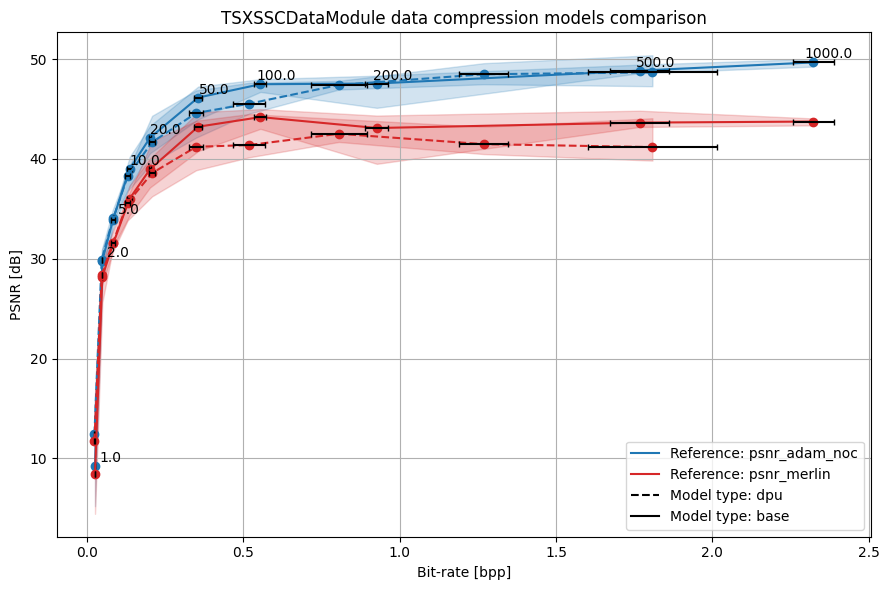

In [10]:
fig, ax = plt.subplots(figsize=(9, 6))
colors = {"psnr_adam_noc": "tab:blue", "psnr_merlin": "tab:red"}
linestyles = {"dpu": "--", "base": "-"}
for ref in ["psnr_adam_noc", "psnr_merlin"]:
    # Set color based on reference
    color = colors[ref]
    for j, model_name in enumerate(model_statistics[data_name]):
        # Set linestyle based on model name (DPU suitability)
        linestyle = linestyles["dpu"] if "dpu" in model_name else linestyles["base"]

        bpp_mean = model_statistics[data_name][model_name]["test/bpp mean"].astype(float)
        bpp_std = model_statistics[data_name][model_name]["test/bpp std"].astype(float)
        psnr_mean = model_statistics[data_name][model_name][f"test/{ref} mean"].astype(float)
        psnr_std = model_statistics[data_name][model_name][f"test/{ref} std"].astype(float)
        # Main line
        ax.plot(
            bpp_mean,
            psnr_mean,
            "o-",
            linestyle=linestyle,
            color=color,
            # label=f"{model_name} {ref}",
        )
        # Psnr error bands (min/nmax)
        ax.fill_between(
            bpp_mean,
            model_statistics[data_name][model_name][f"test/{ref} max"].astype(float),
            model_statistics[data_name][model_name][f"test/{ref} min"].astype(float),
            alpha=0.2,
            color=color,
        )
        # # Psnr error bands
        # ax.fill_between(
        #     bpp_mean,
        #     psnr_mean + psnr_std,
        #     psnr_mean - psnr_std,
        #     alpha=0.1,
        #     color="gray",
        # )
        # Bpp error bars
        ax.errorbar(
            bpp_mean,
            psnr_mean,
            xerr=bpp_std,
            fmt="none",
            ecolor="black",
            capsize=2,  # Set the size of the vertical lines at the end of the error bars
        )

# Add text labels for each lmbda value for "ResidualScaleHyperprior"
# Try to find the correct model name (base or with _dpu suffix)
label_model_name = "ResidualScaleHyperpriorPatched_gdn"
if (
    label_model_name not in model_statistics["TSXSSCDataModule"]
    and f"{label_model_name}_dpu" in model_statistics["TSXSSCDataModule"]
):
    label_model_name = f"{label_model_name}_dpu"

if label_model_name in model_statistics["TSXSSCDataModule"]:
    for lmbda, row in model_statistics["TSXSSCDataModule"][label_model_name].iterrows():
        ax.text(
            row["test/bpp mean"] + 0.05,
            row["test/psnr_adam_noc mean"] + 0.1,
            f"{lmbda}",
            ha="center",
            va="bottom",
        )

ax.set_title("TSXSSCDataModule data compression models comparison")
ax.set_xlabel("Bit-rate [bpp]")
ax.set_ylabel("PSNR [dB]")
ax.grid()

# Do a legend with the colors and linestyles
for key, value in colors.items():
    ax.plot([], [], color=value, label=f"Reference: {key}")
for key, value in linestyles.items():
    ax.plot([], [], color="black", linestyle=value, label=f"Model type: {key}")
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc="lower right")

plt.tight_layout()
plt.show()

### Plot only the ResidualSimpleAE 

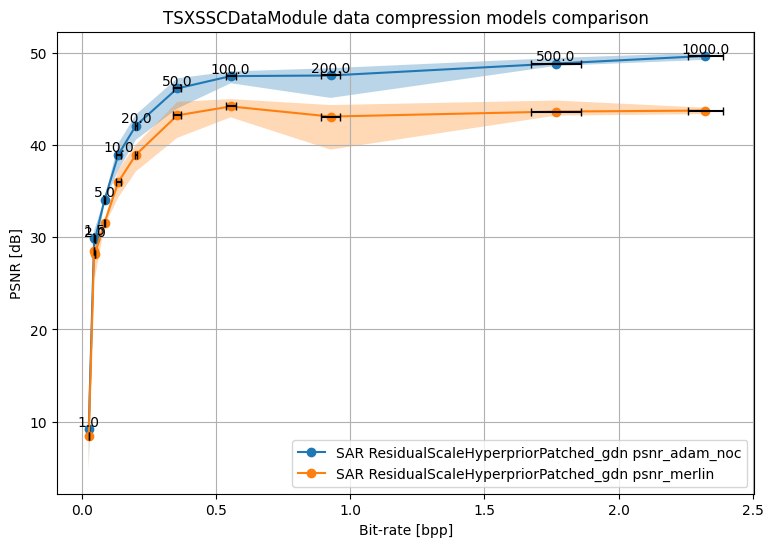

In [11]:
fig, ax = plt.subplots(figsize=(9, 6))
for ref in ["psnr_adam_noc", "psnr_merlin"]:
    for model_name in ["ResidualScaleHyperpriorPatched_gdn"]:  # , "ResidualSimpleAE_gdn"]:
        bpp_mean = model_statistics[data_name][model_name]["test/bpp mean"].astype(float)
        bpp_std = model_statistics[data_name][model_name]["test/bpp std"].astype(float)
        psnr_mean = model_statistics[data_name][model_name][f"test/{ref} mean"].astype(float)
        psnr_std = model_statistics[data_name][model_name][f"test/{ref} std"].astype(float)
        # Main line
        ax.plot(
            bpp_mean,
            psnr_mean,
            "o-",
            # color=color_list[j],
            label=f"SAR {model_name} {ref}",
        )
        # Psnr error bands (min/nmax)
        ax.fill_between(
            bpp_mean,
            model_statistics[data_name][model_name][f"test/{ref} max"].astype(float),
            model_statistics[data_name][model_name][f"test/{ref} min"].astype(float),
            alpha=0.3,
            # color=color_list[j],
        )
        # Bpp error bars
        ax.errorbar(
            bpp_mean,
            psnr_mean,
            xerr=bpp_std,
            fmt="none",
            ecolor="black",
            capsize=3,  # Set the size of the vertical lines at the end of the error bars
        )

# Add text labels for each lmbda value for "ResidualScaleHyperprior"
for lmbda, row in model_statistics["TSXSSCDataModule"][model_name].iterrows():
    ax.text(
        row["test/bpp mean"],
        row["test/psnr_adam_noc mean"],
        f"{lmbda}",
        ha="center",
        va="bottom",
    )

ax.set_title("TSXSSCDataModule data compression models comparison")
ax.set_xlabel("Bit-rate [bpp]")
ax.set_ylabel("PSNR [dB]")
ax.legend()
ax.grid()

# plt.tight_layout()
plt.show()

##### JPEG and traditionnal codecs results


##### Saving dictionnaries in a JSON file


In [ ]:
# # --- Store the JPEG results as a single JSON file ---
# # Put all dictionaries in a list
# jpeg_dicts_to_save = [
#     jpeg_rgb_mini_dict,
#     jpeg_rgb_full_dict,
#     jpeg_sar_mini_dict,
#     jpeg_sar_full_dict,
#     jpeg_sar_as_rgb_mini_dict,
#     jpeg_sar_as_rgb_full_dict,
# ]

# # Save dictionaries to a JSON file
# with open("results/JPEG_compression_results.json", "w") as f:
#     json.dump(jpeg_dicts_to_save, f)

##### Loading dictionnaries from a JSON file


In [ ]:
# --- Load the JPEG results from the JSON file ---
# Load dictionaries from the JSON file
with open("results/JPEG_compression_results.json", "r") as f:
    jpeg_dicts_loaded = json.load(f)
# Get individual dictionaries
jpeg_rgb_mini_dict = jpeg_dicts_loaded[0]
jpeg_rgb_full_dict = jpeg_dicts_loaded[1]
jpeg_sar_mini_dict = jpeg_dicts_loaded[2]
jpeg_sar_full_dict = jpeg_dicts_loaded[3]
jpeg_sar_as_rgb_mini_dict = jpeg_dicts_loaded[4]
jpeg_sar_as_rgb_full_dict = jpeg_dicts_loaded[5]
# Create dataframes from the results, the index is the quality parameter (QP)
# RGB
jpeg_rgb_mini = pd.DataFrame(
    jpeg_rgb_mini_dict["results"], index=jpeg_rgb_mini_dict["quality_parameters"]
)
jpeg_rgb_full = pd.DataFrame(
    jpeg_rgb_full_dict["results"], index=jpeg_rgb_full_dict["quality_parameters"]
)
# SAR (Single-Pol: 1 channel per image)
jpeg_sar_mini = pd.DataFrame(
    jpeg_sar_mini_dict["results"], index=jpeg_sar_mini_dict["quality_parameters"]
)
jpeg_sar_full = pd.DataFrame(
    jpeg_sar_full_dict["results"], index=jpeg_sar_full_dict["quality_parameters"]
)
# SAR as RGB (`Fake-RGB``: 3 channels per image, 3rd channel filled with zeros.)
jpeg_sar_as_rgb_mini = pd.DataFrame(
    jpeg_sar_as_rgb_mini_dict["results"],
    index=jpeg_sar_as_rgb_mini_dict["quality_parameters"],
)
jpeg_sar_as_rgb_full = pd.DataFrame(
    jpeg_sar_as_rgb_full_dict["results"],
    index=jpeg_sar_as_rgb_full_dict["quality_parameters"],
)

## Plots


##### Main common PSNR plot


In [ ]:
available_datasets = {"TSXSSCDataModule": "SAR"}

fig, ax = plt.subplots(figsize=(9, 6))
# color_list = ["darkcyan", "peru", "palegreen", "slategray"]
for i, data_name in enumerate(model_statistics):
    for j, model_name in enumerate(model_statistics[data_name]):
        # Main line
        ax.plot(
            model_statistics[data_name][model_name]["test/bpp mean"].astype(float),
            model_statistics[data_name][model_name]["test/psnr mean"].astype(float),
            "o-",
            # color=color_list[j],
            label=available_datasets[data_name] + " " + model_name,
        )
        # Psnr error bands
        ax.fill_between(
            model_statistics[data_name][model_name]["test/bpp mean"].astype(float),
            model_statistics[data_name][model_name]["test/psnr mean"].astype(float)
            + model_statistics[data_name][model_name]["test/psnr std"].astype(float),
            model_statistics[data_name][model_name]["test/psnr mean"].astype(float)
            - model_statistics[data_name][model_name]["test/psnr std"].astype(float),
            alpha=0.3,
            # color=color_list[j],
        )
        # Bpp error bars
        ax.errorbar(
            model_statistics[data_name][model_name]["test/bpp mean"].astype(float),
            model_statistics[data_name][model_name]["test/psnr mean"].astype(float),
            xerr=model_statistics[data_name][model_name]["test/bpp std"].astype(float),
            fmt="none",
            ecolor="black",
            capsize=3,  # Set the size of the vertical lines at the end of the error bars
        )

# # Add the main line for JPEG RGB
# ax.plot(
#     jpeg_rgb_mini["bpp"],
#     jpeg_rgb_mini["psnr-rgb"],
#     "o-",
#     label="RGB-mini JPEG",
# )
# ax.plot(
#     jpeg_rgb_full["bpp"],
#     jpeg_rgb_full["psnr-rgb"],
#     "o-",
#     label="RGB-full JPEG",
# )
# # Add the main line for JPEG SAR
# ax.plot(
#     jpeg_sar_mini["bpp"],
#     jpeg_sar_mini["psnr-rgb"],
#     "o-",
#     label="SAR-mini JPEG",
# )
# ax.plot(
#     jpeg_sar_full["bpp"],
#     jpeg_sar_full["psnr-rgb"],
#     "o-",
#     label="SAR JPEG",
# )
# # Add the main line for JPEG SAR as RGB
# ax.plot(
#     jpeg_sar_as_rgb_mini["bpp"],
#     jpeg_sar_as_rgb_mini["psnr-rgb"],
#     "o-",
#     label="SAR as RGB-mini JPEG",
# )
# ax.plot(
#     jpeg_sar_as_rgb_full["bpp"],
#     jpeg_sar_as_rgb_full["psnr-rgb"],
#     "o-",
#     label="SAR as RGB-full JPEG",
# )

# Add text labels for each lmbda value for "ResidualScaleHyperprior"
for lmbda, row in model_statistics["TSXSSCDataModule"]["ResidualScaleHyperprior"].iterrows():
    ax.text(
        row["test/bpp mean"],
        row["test/psnr mean"],
        f"{lmbda}",
        ha="center",
        va="bottom",
    )

ax.set_title("TSXSSCDataModule data compression models comparison")
ax.set_xlabel("Bit-rate [bpp]")
ax.set_ylabel("PSNR [dB]")
ax.legend()
ax.grid()

plt.tight_layout()
plt.show()

##### Eurosat RGB PSNR plot


In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))
for j, model_name in enumerate(model_statistics["EuroSATRGBDataModule"]):
    # Main line
    ax.plot(
        model_statistics["EuroSATRGBDataModule"][model_name]["test/bpp mean"].astype(float),
        model_statistics["EuroSATRGBDataModule"][model_name]["test/psnr mean"].astype(float),
        "o-",
        label=model_name,
    )
    # Psnr error bands
    ax.fill_between(
        model_statistics["EuroSATRGBDataModule"][model_name]["test/bpp mean"].astype(float),
        model_statistics["EuroSATRGBDataModule"][model_name]["test/psnr mean"].astype(float)
        + model_statistics["EuroSATRGBDataModule"][model_name]["test/psnr std"].astype(float),
        model_statistics["EuroSATRGBDataModule"][model_name]["test/psnr mean"].astype(float)
        - model_statistics["EuroSATRGBDataModule"][model_name]["test/psnr std"].astype(float),
        alpha=0.3,
    )
    # # Bpp error bars
    # ax.errorbar(
    #     model_statistics["EuroSATRGBDataModule"][model_name]["test/bpp mean"].astype(
    #         float
    #     ),
    #     model_statistics["EuroSATRGBDataModule"][model_name]["test/psnr mean"].astype(
    #         float
    #     ),
    #     xerr=model_statistics["EuroSATRGBDataModule"][model_name][
    #         "test/bpp std"
    #     ].astype(float),
    #     fmt="none",
    #     ecolor="black",
    #     capsize=3,  # Set the size of the vertical lines at the end of the error bars
    # )
# Add the main line for JPEG
ax.plot(
    jpeg_rgb_full["bpp"],
    jpeg_rgb_full["psnr-rgb"],
    "o-",
    label="JPEG",
)
# ax.set_title("EuroSAT-RGB data compression models comparison")
ax.set_xlabel("Bit-rate [bpp]")
# Set the x-axis limits
plt.xlim(0, 4)
ax.set_ylabel("PSNR [dB]")
ax.grid()
# Custom legend (re-ordered)
handles, labels = ax.get_legend_handles_labels()
label_handle_dict = dict(zip(labels, handles))
custom_order = [
    "mbt2018",
    "mbt2018-mean",
    "bmshj2018-hyperprior",
    "bmshj2018-factorized",
    "JPEG",
]
sorted_labels = [label for label in custom_order if label in label_handle_dict]
sorted_handles = [label_handle_dict[label] for label in sorted_labels]
ax.legend(sorted_handles, sorted_labels, loc="lower right", fontsize=16)

# Add text labels for each lmbda value for "mbt2018"
for lmbda, row in model_statistics["EuroSATRGBDataModule"]["mbt2018"].iterrows():
    ax.text(
        row["test/bpp mean"],
        row["test/psnr mean"] + 0.1,
        f"{lmbda}",
        ha="center",
        va="bottom",
    )
# Add text labels (quality parameter) for JPEG
for qp, row in jpeg_rgb_full.iterrows():
    ax.text(
        row["bpp"] + 0.03,
        row["psnr-rgb"],
        f"{qp}",
        ha="left",
        va="center",
    )

plt.tight_layout()
plt.show()

##### Eurosat SAR PSNR plot


In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))
# Remove some datapoints from the dataframe
reduced_jpeg_sar_full = jpeg_sar_full.drop(45)
for j, model_name in enumerate(model_statistics["EuroSATSARDataModule"]):
    # Main line
    ax.plot(
        model_statistics["EuroSATSARDataModule"][model_name]["test/bpp mean"].astype(float),
        model_statistics["EuroSATSARDataModule"][model_name]["test/psnr mean"].astype(float),
        "o-",
        label=model_name,
    )
    # Psnr error bands
    ax.fill_between(
        model_statistics["EuroSATSARDataModule"][model_name]["test/bpp mean"].astype(float),
        model_statistics["EuroSATSARDataModule"][model_name]["test/psnr mean"].astype(float)
        + model_statistics["EuroSATSARDataModule"][model_name]["test/psnr std"].astype(float),
        model_statistics["EuroSATSARDataModule"][model_name]["test/psnr mean"].astype(float)
        - model_statistics["EuroSATSARDataModule"][model_name]["test/psnr std"].astype(float),
        alpha=0.3,
    )
    # # Bpp error bars
    # ax.errorbar(
    #     model_statistics["EuroSATSARDataModule"][model_name]["test/bpp mean"].astype(
    #         float
    #     ),
    #     model_statistics["EuroSATSARDataModule"][model_name]["test/psnr mean"].astype(
    #         float
    #     ),
    #     xerr=model_statistics["EuroSATSARDataModule"][model_name][
    #         "test/bpp std"
    #     ].astype(float),
    #     fmt="none",
    #     ecolor="black",
    #     capsize=3,  # Set the size of the vertical lines at the end of the error bars
    # )
# Add the main line for JPEG SAR
ax.plot(
    reduced_jpeg_sar_full["bpp"],
    reduced_jpeg_sar_full["psnr-rgb"],
    "o-",
    label="JPEG",
)
ax.plot(
    jpeg_sar_as_rgb_full["bpp"],
    jpeg_sar_as_rgb_full["psnr-rgb"],
    "o-",
    label="SAR as RGB-full JPEG",
)
# ax.set_title(f"EuroSAT SAR data compression models comparison")
ax.set_xlabel("Bit-rate [bpp]")
# Set the x-axis limits
# plt.xlim(0, 4)
ax.set_ylabel("PSNR [dB]")
ax.grid()
# Custom legend (re-ordered)
handles, labels = ax.get_legend_handles_labels()
label_handle_dict = dict(zip(labels, handles))
custom_order = [
    "mbt2018",
    "mbt2018-mean",
    "bmshj2018-hyperprior",
    "bmshj2018-factorized",
    "JPEG",
]
sorted_labels = [label for label in custom_order if label in label_handle_dict]
sorted_handles = [label_handle_dict[label] for label in sorted_labels]
ax.legend(sorted_handles, sorted_labels, loc="lower right", fontsize=16)

# Add text labels for each lmbda value for "mbt2018"
for lmbda, row in model_statistics["EuroSATSARDataModule"]["mbt2018"].iterrows():
    ax.text(
        row["test/bpp mean"],
        row["test/psnr mean"],
        f"{lmbda}",
        ha="center",
        va="bottom",
    )
# Add text labels (quality parameter) for JPEG
for qp, row in reduced_jpeg_sar_full[:8].iterrows():
    ax.text(
        row["bpp"] + 0.03,
        row["psnr-rgb"],
        f"{qp}",
        ha="left",
        va="center",
    )

plt.tight_layout()
plt.show()

##### Eurosat SAR SSIM plot


In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))
# color_list = ["darkcyan", "peru", "palegreen", "slategray"]
for j, model_name in enumerate(model_statistics["EuroSATSARDataModule"]):
    # Main line
    ax.plot(
        model_statistics["EuroSATSARDataModule"][model_name]["test/bpp mean"].astype(float),
        model_statistics["EuroSATSARDataModule"][model_name]["test/ssim mean"].astype(float),
        "o-",
        # color=color_list[j],
        label=model_name,
    )
    # Psnr error bands
    ax.fill_between(
        model_statistics["EuroSATSARDataModule"][model_name]["test/bpp mean"].astype(float),
        model_statistics["EuroSATSARDataModule"][model_name]["test/ssim mean"].astype(float)
        + model_statistics["EuroSATSARDataModule"][model_name]["test/ssim std"].astype(float),
        model_statistics["EuroSATSARDataModule"][model_name]["test/ssim mean"].astype(float)
        - model_statistics["EuroSATSARDataModule"][model_name]["test/ssim std"].astype(float),
        alpha=0.3,
        # color=color_list[j],
    )
    # Bpp error bars
    ax.errorbar(
        model_statistics["EuroSATSARDataModule"][model_name]["test/bpp mean"].astype(float),
        model_statistics["EuroSATSARDataModule"][model_name]["test/ssim mean"].astype(float),
        xerr=model_statistics["EuroSATSARDataModule"][model_name]["test/bpp std"].astype(float),
        fmt="none",
        ecolor="black",
        capsize=3,  # Set the size of the vertical lines at the end of the error bars
    )
# Add the main line for JPEG SAR
ax.plot(
    reduced_jpeg_sar_full[:9]["bpp"],
    reduced_jpeg_sar_full[:9]["ssim-rgb"],
    "o-",
    label="JPEG",
)
ax.plot(
    jpeg_sar_as_rgb_full[:9]["bpp"],
    jpeg_sar_as_rgb_full[:9]["ssim-rgb"],
    "o-",
    label="SAR as RGB-full JPEG",
)
ax.set_title(f"EuroSAT SAR data compression models comparison")
ax.set_xlabel("Bit-rate [bpp]")
ax.set_ylabel("SSIM")
ax.legend(loc="lower right")
ax.grid()

# Add text labels for each lmbda value for "mbt2018"
for lmbda, row in model_statistics["EuroSATSARDataModule"]["mbt2018"].iterrows():
    ax.text(
        row["test/bpp mean"],
        row["test/ssim mean"],
        f"{lmbda}",
        ha="center",
        va="bottom",
    )
# Add text labels (quality parameter) for JPEG
for qp, row in reduced_jpeg_sar_full[:9].iterrows():
    ax.text(
        row["bpp"] + 0.03,
        row["ssim-rgb"],
        f"{qp}",
        ha="left",
        va="center",
    )
plt.tight_layout()
plt.show()

##### Compare error bands method


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

for model_name in model_statistics:
    # Plot the main lines
    for ax in [ax1, ax2]:
        ax.plot(
            model_statistics[model_name]["test/bpp mean"].astype(float),
            model_statistics[model_name]["test/psnr mean"].astype(float),
            "o-",
            label=model_name,
        )
    # Plot the different error bands on each ax
    ax1.fill_between(
        model_statistics[model_name]["test/bpp mean"].astype(float),
        model_statistics[model_name]["test/psnr min"].astype(float),
        model_statistics[model_name]["test/psnr max"].astype(float),
        alpha=0.2,
    )
    ax2.fill_between(
        model_statistics[model_name]["test/bpp mean"].astype(float),
        model_statistics[model_name]["test/psnr mean"].astype(float)
        + model_statistics[model_name]["test/psnr std"].astype(float),
        model_statistics[model_name]["test/psnr mean"].astype(float)
        - model_statistics[model_name]["test/psnr std"].astype(float),
        alpha=0.2,
    )
# Subplot 1: "min and max" error bands
ax1.set_title("Min and Max Error Bands")
ax1.set_xlabel("Bits per pixel")
ax1.set_ylabel("PSNR (dB)")
ax1.legend(loc="lower right")
ax1.grid()

# Subplot 2: "std" error bands
ax2.set_title("Std Error Bands")
ax2.set_xlabel("Bits per pixel")
ax2.set_ylabel("PSNR (dB)")
ax2.legend(loc="lower right")
ax2.grid()

# Add the lmbda values as text, for each point, only for the "mbt2018" model
for lmbda, row in model_statistics["mbt2018"].iterrows():
    ax1.text(
        row["test/bpp mean"],
        row["test/psnr mean"],
        f"{lmbda}",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()